In [2]:
import numpy as np
import matplotlib.pyplot as plt

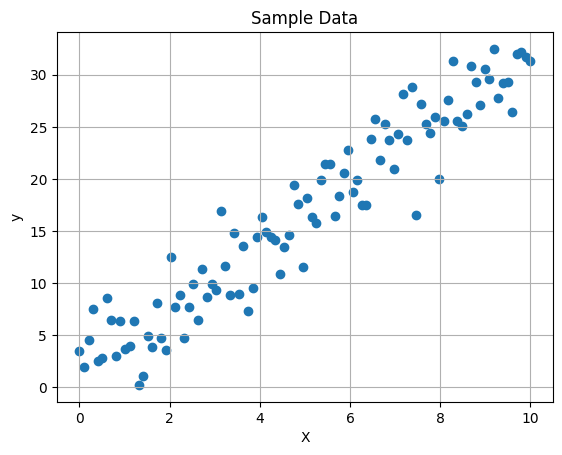

In [12]:
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 3 * X.squeeze() + 2 + np.random.normal(0, 3, 100)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Sample Data")
plt.grid()
plt.show()

In [16]:
# 표준화
X_mean = X.mean(axis = 0)
X_std = X.std(axis = 0)

X_scaled = (X - X_mean) / X_std

In [31]:
def train_regression(X, y, penalty=None, alpha=0.1, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0

    losses = []

    for epoch in range(epochs):
        # 예측
        y_pred = X @ w + b
        error = y_pred - y

        # loss
        mse_loss = np.mean(error ** 2)

        # 기본 gradient
        dw = (2 / n_samples) * (X.T @ error)
        db = (2 / n_samples) * np.sum(error)

        # Regularization
        if penalty == "ridge":
            mse_loss += alpha * np.sum(w ** 2)
            dw += 2 * alpha * w

        elif penalty == "lasso":
            mse_loss += alpha * np.sum(np.abs(w))
            dw += alpha * np.sign(w)

        # 업데이트
        w -= lr * dw
        b -= lr * db

        losses.append(mse_loss)

    return w, b, losses


In [33]:
# 학습 코드
w_linear, b_linear, loss_linear = train_regression(
    X_scaled, y, penalty=None, lr=0.01, epochs=2000
)

w_ridge, b_ridge, loss_ridge = train_regression(
    X_scaled, y, penalty="ridge", alpha=0.1, lr=0.01, epochs=2000
)

w_lasso, b_lasso, loss_lasso = train_regression(
    X_scaled, y, penalty="lasso", alpha=0.1, lr=0.01, epochs=2000
)

print("Linear Regression")
print("w:", w_linear, "b:", b_linear)

print("\nRidge Regression")
print("w:", w_ridge, "b:", b_ridge)

print("\nLasso Regression")
print("w:", w_lasso, "b:", b_lasso)

Linear Regression
w: [8.86794772] b: 16.688460447817633

Ridge Regression
w: [8.06177065] b: 16.688460447817633

Lasso Regression
w: [8.81794772] b: 16.688460447817633


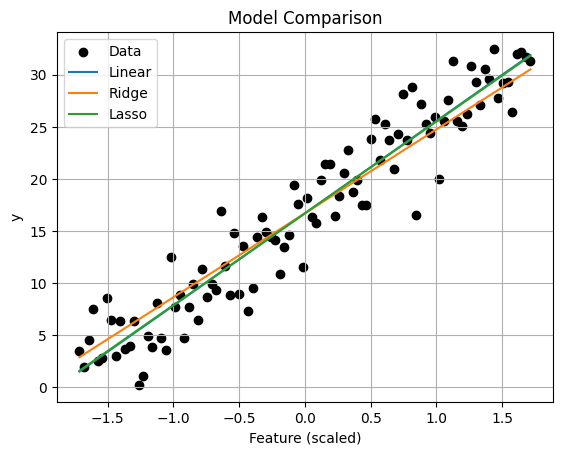

In [35]:
# 예측값
y_pred_linear = X_scaled @ w_linear + b_linear
y_pred_ridge = X_scaled @ w_ridge + b_ridge
y_pred_lasso = X_scaled @ w_lasso + b_lasso

# 정렬
sorted_idx = np.argsort(X_scaled[:, 0])

plt.scatter(X_scaled[:, 0], y, color="black", label="Data")

plt.plot(X_scaled[sorted_idx, 0], y_pred_linear[sorted_idx], label="Linear")
plt.plot(X_scaled[sorted_idx, 0], y_pred_ridge[sorted_idx], label="Ridge")
plt.plot(X_scaled[sorted_idx, 0], y_pred_lasso[sorted_idx], label="Lasso")

plt.xlabel("Feature (scaled)")
plt.ylabel("y")
plt.title("Model Comparison")
plt.legend()
plt.grid()
plt.show()